# SADAR: Exploratory Data Analysis

Smart Anomaly Detection for Aviation Routes. ADS-B (Automatic Dependent Surveillance-Broadcast) surveillance data over Madrid-Barajas (LEMD, the airport's ICAO code), collected from the OpenSky Network.

The purpose of this notebook is to understand the raw data before any modelling. We confirm the dataset's basic figures, characterise its quality, locate the few real events it contains, and decide which trajectories should be excluded from the normal training set used later by the one-class anomaly-detection models.

In [1]:
import os
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
from IPython.display import display

plt.rcParams['figure.figsize'] = (9, 4)
plt.rcParams['axes.grid'] = True
pd.set_option('display.max_columns', 30)

DATA_DIR = os.environ.get('SADAR_DATA_DIR', 'data/raw')
print('Reading raw parquet from:', DATA_DIR)

Reading raw parquet from: /Users/rup/Documents/DevelopmentLocal/SADAR/data/raw


## 1. Load and merge

The analysis begins by combining the raw days into a single table. We read every daily parquet file for the airport, tag each row with the date it came from so any measurement can be traced back to its day, and concatenate the result. Sorting by flight and time then lets each trajectory be read in order, from its first sample to its last.

In [2]:
def load_adsb(data_dir):
    files = sorted(glob.glob(os.path.join(data_dir, 'lemd_*.parquet')))
    frames = []
    for f in files:
        d = pd.read_parquet(f)
        d['source_date'] = os.path.basename(f).split('__')[0].replace('lemd_', '')
        frames.append(d)
    df = pd.concat(frames, ignore_index=True).sort_values(['flight_id', 'time'])
    return df, files

df, used_files = load_adsb(DATA_DIR)
print('Daily files used:', len(used_files))
print('Total rows:', f'{len(df):,}')
print('Distinct flights:', f"{df['flight_id'].nunique():,}")
print('In-memory size (MB):', round(df.memory_usage(deep=True).sum() / 1e6, 1))

Daily files used: 18
Total rows: 3,429,638
Distinct flights: 19,057
In-memory size (MB): 737.8


## 2. Schema and types

Before relying on any figure we inspect the structure of the data: its 21 columns, the type of each one, and how time is stored (a raw Unix timestamp together with a ready-made UTC datetime). Printing the minimum, median and maximum of the main continuous variables is a fast way to detect physically impossible values, such as negative speeds or altitudes well outside the expected range.

In [3]:
# 'time' is just a Unix timestamp; 'time_utc' already comes as a proper date
print('Columns:', len(df.columns))
display(df.dtypes.to_frame('dtype'))

df['dt'] = pd.to_datetime(df['time'], unit='s', utc=True)

ranges = df[['baroaltitude', 'geoaltitude', 'velocity_kmh', 'vertrate',
             'dist_to_runway_m', 'heading']].describe().T[['min', '50%', 'max']]
display(ranges)

Columns: 22


,dtype
time,int64
icao24,str
lat,float64
lon,float64
baroaltitude,float64
geoaltitude,float64
velocity,float64
heading,float64
vertrate,float64
callsign,str


,min,50%,max
baroaltitude,-365.760000,4366.260000,38648.640000
geoaltitude,-304.800000,4686.300000,39006.780000
velocity_kmh,0.000000,527.218114,6153.974158
vertrate,-139.476480,-0.650240,165.811200
dist_to_runway_m,11.447052,35211.168852,199999.879356
heading,-0.000000,197.007947,359.921405


## 3. Null analysis

Surveillance data is rarely complete, so we measure how much is missing in each column. This guides the cleaning strategy for Phase 2: short interruptions can be filled by interpolation, whereas trajectories with too many holes are better discarded than patched. It also shows which columns are reliable enough for the models to depend on.

,null_%
geoaltitude,24.79
baroaltitude,13.48
velocity,13.37
heading,13.37
velocity_kmh,13.37
vertrate,13.34
callsign,2.45
squawk,1.97
flight_id,0.00
source_date,0.00


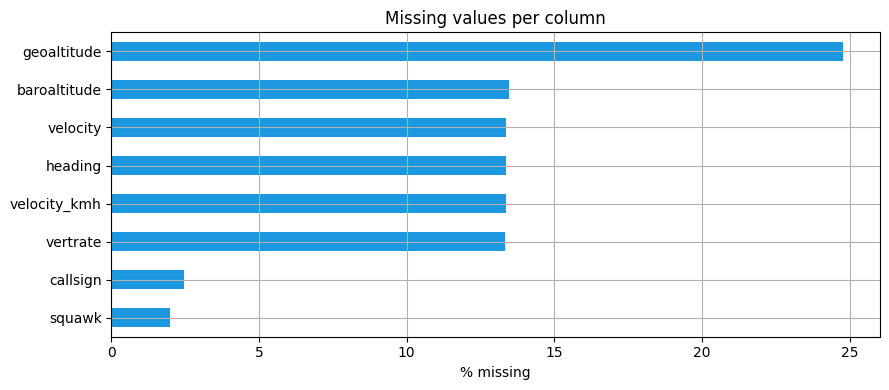

In [4]:
null_pct = (df.isna().mean() * 100).round(2).sort_values(ascending=False)
display(null_pct.to_frame('null_%'))

top = null_pct[null_pct > 0]
ax = top.plot.barh(color='#1B98E0')
ax.set_xlabel('% missing')
ax.set_title('Missing values per column')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

The missing data is concentrated almost entirely in the movement fields: speed, heading, vertical rate and the two altitudes. These are gaps in radio coverage rather than corrupt records. GPS altitude (geoaltitude) is the least complete, so the models will rely on pressure altitude (baroaltitude) instead. Position and identity fields are essentially complete.

## 4. Distributions

We next examine how the main variables are distributed. The flight-phase bar chart shows how the records split between ground, climb, cruise, descent and approach, while the histograms reveal the typical ranges of altitude, speed, distance to the runway and vertical rate. Heading is shown on a polar chart because it is an angle, and a circular view makes the two dominant runway directions immediately visible. That same circular nature is why heading is later encoded as sin and cos, so that 359 degrees and 1 degree sit beside each other rather than at opposite ends of the scale.

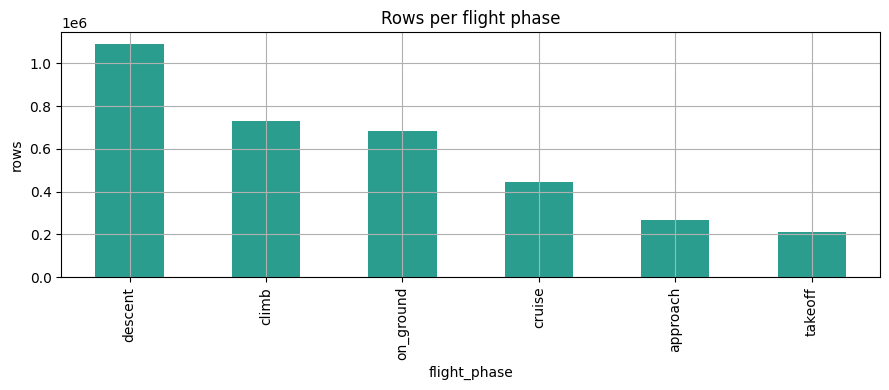

,rows
flight_phase,
descent,1090369
climb,731531
on_ground,684742
cruise,446580
approach,265192
takeoff,211224


In [5]:
phase_counts = df['flight_phase'].value_counts()
ax = phase_counts.plot.bar(color='#2A9D8F')
ax.set_title('Rows per flight phase')
ax.set_ylabel('rows')
plt.tight_layout()
plt.show()
display(phase_counts.to_frame('rows'))

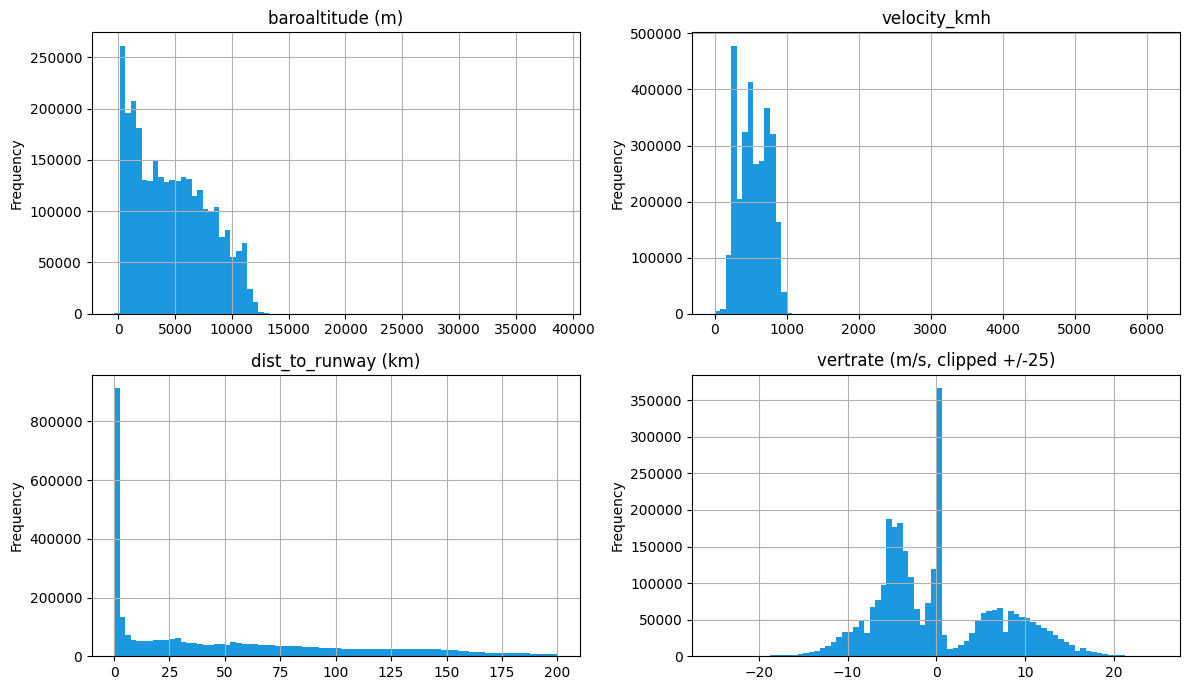

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))

df['baroaltitude'].dropna().plot.hist(bins=80, ax=axes[0, 0], color='#1B98E0')
axes[0, 0].set_title('baroaltitude (m)')

df['velocity_kmh'].dropna().plot.hist(bins=80, ax=axes[0, 1], color='#1B98E0')
axes[0, 1].set_title('velocity_kmh')

(df['dist_to_runway_m'].dropna() / 1000).plot.hist(bins=80, ax=axes[1, 0], color='#1B98E0')
axes[1, 0].set_title('dist_to_runway (km)')

df['vertrate'].dropna().clip(-25, 25).plot.hist(bins=80, ax=axes[1, 1], color='#1B98E0')
axes[1, 1].set_title('vertrate (m/s, clipped +/-25)')

plt.tight_layout()
plt.show()

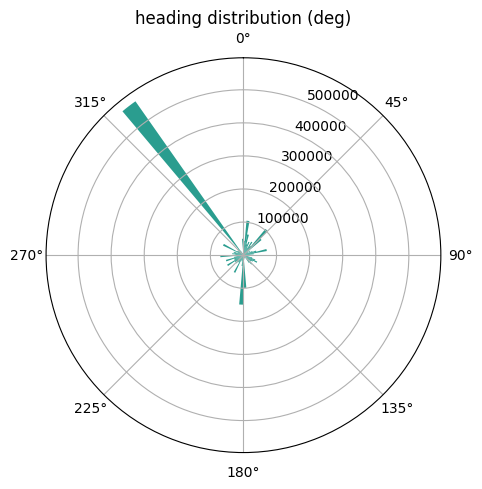

In [7]:
h = df['heading'].dropna().to_numpy()
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111, projection='polar')
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.hist(np.deg2rad(h), bins=72, color='#2A9D8F')
ax.set_title('heading distribution (deg)')
plt.tight_layout()
plt.show()

## 5. Trajectory statistics

These statistics describe the rhythm of the airport and the size of a typical trajectory. We count the distinct flights on each sampled day, the number of points that make up a flight, and how long flights remain within the coverage area. Together they inform the length of the input windows and the minimum trajectory length below which a flight is too short to be useful.

Flights/day  min/median/max: 912 1054 1217


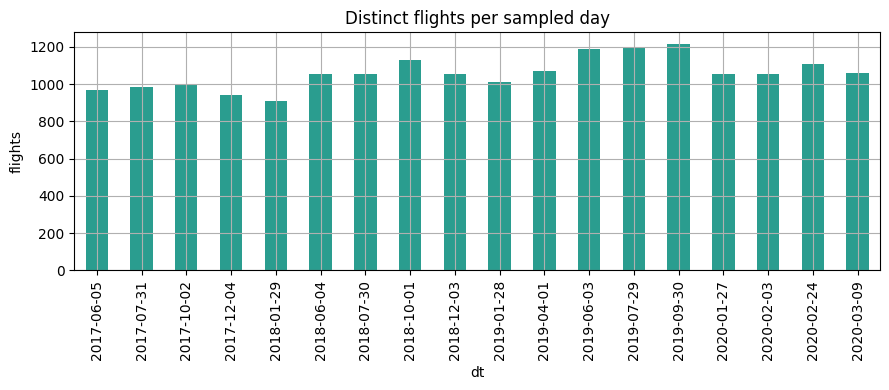

In [8]:
flights_per_day = df.groupby(df['dt'].dt.date)['flight_id'].nunique()
print('Flights/day  min/median/max:',
      int(flights_per_day.min()), int(flights_per_day.median()), int(flights_per_day.max()))
ax = flights_per_day.plot.bar(color='#2A9D8F')
ax.set_title('Distinct flights per sampled day')
ax.set_ylabel('flights')
plt.tight_layout()
plt.show()

Points/flight  min/median/max: 4 175 1606
Duration min  median/max (min): 30.2 297.2


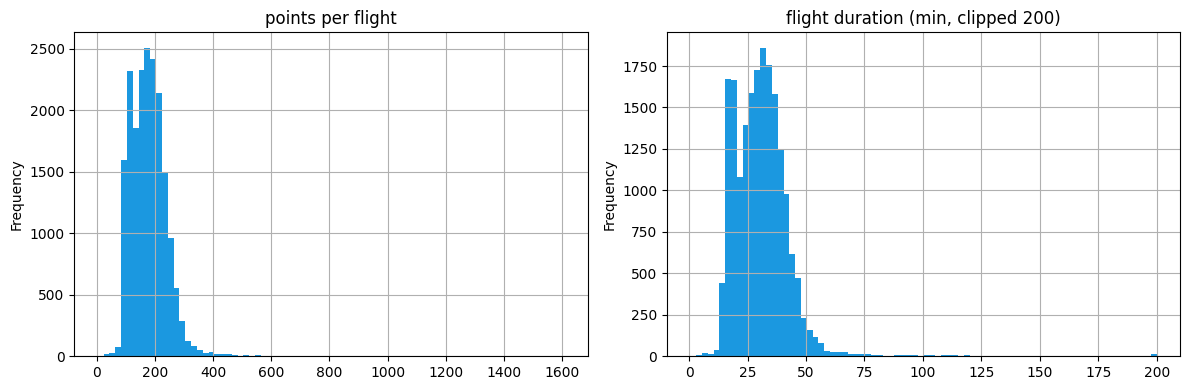

In [9]:
points_per_flight = df.groupby('flight_id').size()
duration_min = (df.groupby('flight_id')['time'].max() - df.groupby('flight_id')['time'].min()) / 60

print('Points/flight  min/median/max:',
      int(points_per_flight.min()), int(points_per_flight.median()), int(points_per_flight.max()))
print('Duration min  median/max (min):',
      round(float(duration_min.median()), 1), round(float(duration_min.max()), 1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
points_per_flight.plot.hist(bins=80, ax=axes[0], color='#1B98E0')
axes[0].set_title('points per flight')
duration_min.clip(0, 200).plot.hist(bins=80, ax=axes[1], color='#1B98E0')
axes[1].set_title('flight duration (min, clipped 200)')
plt.tight_layout()
plt.show()

## 6. Real events: emergency squawks

The nearest thing to a real label in this dataset is the emergency transponder code a crew can set: 7500 for unlawful interference or hijack, 7600 for a radio failure, and 7700 for a general emergency. Only a handful of flights ever transmit one, and they are far too few and too uncertain to train on, so we use them only as illustrations and as a check that a finished model reacts to genuine trouble. For each case we record the callsign, the day, the code that appeared, how long it was held, the closest approach to the runway, and whether the flight landed.

In [10]:
EMERGENCY = {7500: 'hijack', 7600: 'radio failure', 7700: 'general emergency'}
emask = df['squawk'].isin(EMERGENCY)
rows = []
for fid, g in df[df['flight_id'].isin(df.loc[emask, 'flight_id'].unique())].groupby('flight_id'):
    codes = sorted(set(g.loc[g['squawk'].isin(EMERGENCY), 'squawk'].astype(int)))
    rows.append({
        'flight_id': fid,
        'callsign': g['callsign'].dropna().unique().tolist(),
        'date': g['source_date'].iloc[0],
        'squawk(s)': [f'{c} ({EMERGENCY[c]})' for c in codes],
        'emergency_points': int(emask[g.index].sum()),
        'total_points': len(g),
        'min_dist_to_rwy_km': round(float(g['dist_to_runway_m'].min()) / 1000, 1),
        'landed_on_ground': bool(g['onground'].any()),
    })
cases = pd.DataFrame(rows)
display(cases)

,flight_id,callsign,date,squawk(s),emergency_points,total_points,min_dist_to_rwy_km,landed_on_ground
0,3420ca_1501530490,[IBE2845],20170731,[7500 (hijack)],3,171,0.8,False
1,4b161e_1580715790,[SWR202Y],20200203,[7700 (general emergency)],1,156,0.8,True
2,4ca564_1548700030,"[RYR61AD, ]",20190128,[7600 (radio failure)],1,173,0.3,True
3,738051_1506930700,[ELY395],20171002,[7700 (general emergency)],5,162,0.8,True


IBE2845 transmitted the hijack code for only a few points before landing normally, which points to a transponder glitch rather than a real hijack. The most plausible genuine emergency is ELY395 (El Al), which declared 7700 close to the runway and landed. These four flights serve as anchors to sanity-check the models, never as training data.

## 7. Go-arounds (strict rule)

A go-around is an aborted landing: the aircraft descends almost to the runway, breaks off the approach and climbs away to try again or divert. We detect it with a deliberately strict rule to avoid over-counting. The flight must come within 5 km of the runway while descending, then show a sustained positive vertical rate and re-enter a climb or takeoff phase. Go-arounds are normal but uncommon, and because they look unusual we remove them from the training set so the models do not learn the manoeuvre as everyday behaviour.

In [11]:
def is_go_around(g):
    g = g.sort_values('time')
    near = g['dist_to_runway_m'] < 5000  # within 5 km of the runway
    if not near.any():
        return False
    idx = np.where(near.to_numpy())[0]
    before = g.iloc[: idx[-1] + 1]   # everything up to the last point near the runway
    after = g.iloc[idx[0]:]          # everything from the first point near the runway on
    # did it drop toward the runway and then climb away again? (vertrate is + up, - down)
    descended = (before['vertrate'].fillna(0) < -1).any()
    climbed_after = (after['vertrate'].fillna(0) > 2).sum() >= 3
    phase_climb = after['flight_phase'].isin(['climb', 'takeoff']).any()
    return bool(descended and climbed_after and phase_climb)

go_around = df.groupby('flight_id').apply(is_go_around, include_groups=False)
go_around_ids = go_around[go_around].index
print('Go-around flights (strict rule):', int(go_around.sum()),
      f'({100 * go_around.mean():.2f}% of flights)')

Go-around flights (strict rule): 100 (0.52% of flights)


## 8. Transponder gaps

A transponder gap is a stretch in which the aircraft stops being heard. For each flight we consider only the airborne samples and flag a gap whenever more than 120 seconds pass between two consecutive points. A dropout can look suspicious, but in this dataset the gaps are almost always holes in ground-receiver coverage, so we treat them as an ordinary characteristic of the data rather than as evidence of an incident.

In [12]:
def has_airborne_gap(g, threshold_s=120):
    air = g.loc[g['onground'] == False, 'time']
    if len(air) < 2:
        return False
    return bool((air.sort_values().diff().dropna() > threshold_s).any())

gaps = df.groupby('flight_id').apply(has_airborne_gap, include_groups=False)
print('Flights with airborne gap > 120 s:', int(gaps.sum()),
      f'({100 * gaps.mean():.1f}% of flights)')

Flights with airborne gap > 120 s: 4608 (24.2% of flights)


## 9. Geographic visualization

The final step turns the data into a map. We draw a sample of ordinary flights around Madrid-Barajas alongside the four emergency-squawk flights, which makes the shape of the traffic apparent: the funnels aircraft follow on final approach and the fans they spread into after departure. Those corridors are the normal pattern the models will learn, so a trajectory that strays outside them is what we later aim to flag. The first plot is a plain longitude and latitude scatter that captures the overall geometry, and the interactive map below places the same flights on real terrain, so that any single trajectory can be zoomed in and followed point by point.

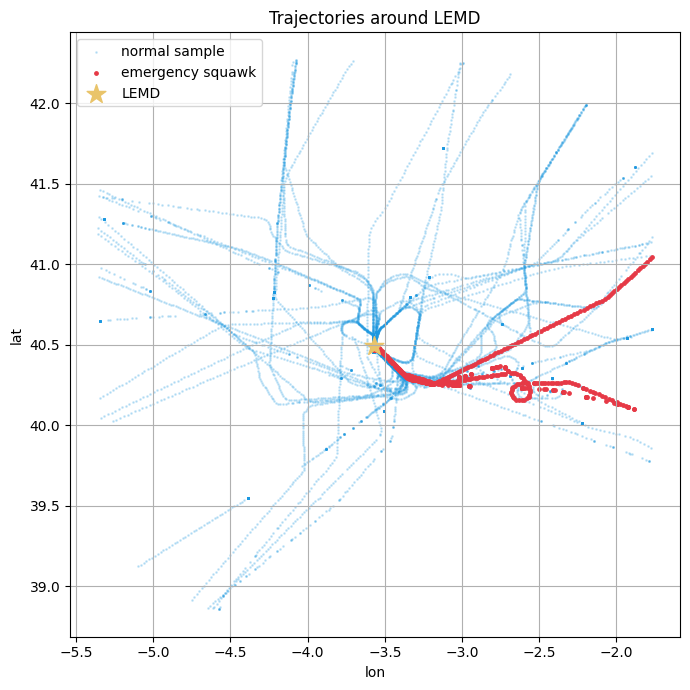

In [13]:
rng = np.random.default_rng(42)
normal_ids = df.loc[~df['flight_id'].isin(go_around_ids), 'flight_id'].unique()
sample_ids = rng.choice(normal_ids, size=min(60, len(normal_ids)), replace=False)
sample = df[df['flight_id'].isin(sample_ids)]
emerg = df[df['flight_id'].isin(cases['flight_id'])]

plt.figure(figsize=(7, 7))
plt.scatter(sample['lon'], sample['lat'], s=1, alpha=0.2, color='#1B98E0', label='normal sample')
plt.scatter(emerg['lon'], emerg['lat'], s=6, color='#E63946', label='emergency squawk')
plt.scatter([-3.5668], [40.4936], marker='*', s=200, color='#E9C46A', label='LEMD')
plt.xlabel('lon'); plt.ylabel('lat'); plt.title('Trajectories around LEMD')
plt.legend(); plt.tight_layout(); plt.show()

In [14]:
map_ids = list(rng.choice(normal_ids, size=min(25, len(normal_ids)), replace=False))
map_df = df[df['flight_id'].isin(map_ids + list(cases['flight_id']))].copy()
map_df['kind'] = np.where(map_df['flight_id'].isin(cases['flight_id']), 'emergency', 'normal')
fig = px.line_map(
    map_df, lat='lat', lon='lon', color='kind', line_group='flight_id',
    color_discrete_map={'normal': '#1B98E0', 'emergency': '#E63946'},
    map_style='open-street-map', zoom=6, height=520,
)
fig.update_layout(margin=dict(l=0, r=0, t=0, b=0))
fig.show()

## 10. Data-quality conclusions

What we verified and what it implies for the modelling phases:

- Volume: 18 sampled days, around 3.43M rows and roughly 19,000 distinct flights, which is ample normal data for one-class learning.
- Nulls: almost all the missing data is in the movement fields (GPS altitude worst, then pressure altitude, speed, heading and vertical rate). These are coverage gaps, not errors. The plan is to interpolate short gaps, drop flights with too many, and prefer pressure altitude over GPS altitude.
- Heading is strongly bimodal along the runway axes, which confirms the sin/cos encoding decision.
- Real events: exactly 4 flights with emergency squawks, held out for validation only.
- Go-arounds (strict rule): a small set of normal but uncommon flights, removed from the training set so the models do not learn them as normal.
- Transponder gaps: a sizeable share of flights have airborne gaps over 120 seconds, treated as a feature, never as an incident label.